# **Tìm hiểu các tính năng và cách sử dụng sản phẩm AutoViz áp dụng trên tập dữ liệu Marketing Campaign**

### **Giới thiệu AutoViz**
- AutoViz là một thư viện Python giúp tự động hóa quá trình trực quan hóa dữ liệu (EDA – Exploratory Data Analysis) với ít dòng code nhất. 

- Nó có thể nhận đầu vào là một file (CSV, txt, JSON) hoặc một pandas.DataFrame. 

- AutoViz tự động phát hiện kiểu biến (số, phân loại, ngày tháng…), kiểm tra chất lượng dữ liệu (missing values, outliers, v.v.), sau đó vẽ các đồ thị phù hợp (histogram, scatter, box plot, heatmap, v.v.). 

- Ngoài ra, AutoViz còn hỗ trợ một số chức năng xử lý dữ liệu (data quality, fix DQ) để gợi ý sửa lỗi dữ liệu. 

- Kết quả thường được xuất dưới dạng bộ đồ thị HTML / interactive plots để dễ xem và chia sẻ. 

Một điểm lưu ý: vì AutoViz cố gắng tạo ra rất nhiều hình, nếu dữ liệu rất lớn hoặc có nhiều cột thì có thể mất thời gian hoặc quá tải trong việc hiển thị.

### **Cài đặt và sử dụng cơ bản**
Cài đặt

Bạn có thể cài đặt AutoViz bằng pip:
pip install autoviz

Hoặc nếu dùng conda:
conda install -c conda-forge autoviz


Giải thích một số tham số quan trọng:

| Tham số             | Ý nghĩa                                   | Ghi chú                                                 |
| ------------------- | ----------------------------------------- | ------------------------------------------------------- |
| `filename`          | file CSV / JSON nếu dùng file             | Nếu dùng DataFrame thì đặt `filename=""` và dùng `dfte` |
| `sep`               | ký tự phân tách (comma, tab, etc.)        | Thường là `","`                                         |
| `depVar`            | tên biến mục tiêu (nếu có)                | giúp AutoViz tập trung vào tương quan với biến mục tiêu |
| `dfte`              | DataFrame dữ liệu                         | dùng nếu bạn đã load dữ liệu vào pandas                 |
| `max_rows_analyzed` | số dòng tối đa để AutoViz phân tích       | nếu dữ liệu rất lớn, nên để giới hạn để không chậm      |
| `max_cols_analyzed` | số cột số (continuous) tối đa để vẽ       | để tránh quá nhiều cột vật liệu số gây rối              |
| `chart_format`      | định dạng đồ thị (`svg`, `png`, v.v.)     | ảnh vector như `svg` dễ zoom                            |
| `save_plot_dir`     | thư mục để lưu đồ thị HTML / file xuất ra | nếu bạn muốn lưu để xem sau                             |

Kết quả trả về dft là DataFrame đã được xử lý (có thể đã loại bỏ cột ít thông tin, v.v.). Đồng thời AutoViz sẽ tạo các file đồ thị và báo cáo để bạn mở xem.

### **Áp dụng với Marketing Campaign dataset**

Marketing Campaign dataset thường chứa các biến như:

- Thông tin khách hàng: tuổi, giới tính, thu nhập, số con cái, …

- Giao dịch / hoạt động: số lần mua hàng, chi tiêu, tần suất, phản hồi chiến dịch, v.v.

- Biến mục tiêu: có tham gia chiến dịch hay không, số tiền chi trả hoặc phản hồi (yes/no)

Dưới đây là cách bạn có thể dùng AutoViz để khám phá dataset loại này:

**Bước 1: Chuẩn bị dữ liệu**

- Đảm bảo dữ liệu đã load đúng định dạng, đặt các giá trị thiếu (NaN) hợp lý.

- Nếu có biến ngày/thời gian, bạn có thể chuyển nó thành kiểu datetime trong pandas trước khi gửi vào AutoViz.

- Nếu có biến mục tiêu (ví dụ response hay is_subscribed), bạn đặt tên nó vào depVar.

In [9]:
import autoviz
print(autoviz.__version__)


0.1.905


**Bước 2: Chạy AutoViz**

Shape of your Data Set loaded: (2240, 29)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  1
    Number of Integer-Categorical Columns =  15
    Number of String-Categorical Columns =  2
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  0
    Number of Numeric-Boolean Columns =  7
    Number of Discrete String Columns =  1
    Number of NLP String Columns =  0
    Number of Date Time Columns =  0
    Number of ID Columns =  1
    Number of Columns to Delete =  2
    29 Predictors classified...
        3 variable(s) removed since they were ID or low-information variables
        List of variables removed: ['ID', 'Z_CostContact', 'Z_Revenue']
To fix these data quality issu

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
ID,int64,0.000000,100,0.000000,11191.000000,Possible ID column: drop before modeling step.
Year_Birth,int64,0.000000,2,1893.000000,1996.000000,Column has 3 outliers greater than upper bound (2004.00) or lower than lower bound(1932.00). Cap them or remove them.
Education,object,0.000000,0,,,No issue
Marital_Status,object,0.000000,0,,,"3 rare categories: ['Alone', 'Absurd', 'YOLO']. Group them into a single category or drop the categories."
Income,float64,1.071429,NA,1730.000000,666666.000000,"24 missing values. Impute them with mean, median, mode, or a constant value such as 123., Column has 8 outliers greater than upper bound (118350.50) or lower than lower bound(-14525.50). Cap them or remove them."
Kidhome,int64,0.000000,0,0.000000,2.000000,No issue
Teenhome,int64,0.000000,0,0.000000,2.000000,No issue
Dt_Customer,object,0.000000,29,,,Possible high cardinality column with 663 unique values: Use hash encoding or text embedding to reduce dimension.
Recency,int64,0.000000,4,0.000000,99.000000,No issue
MntWines,int64,0.000000,34,0.000000,1493.000000,Column has 35 outliers greater than upper bound (1225.00) or lower than lower bound(-697.00). Cap them or remove them.


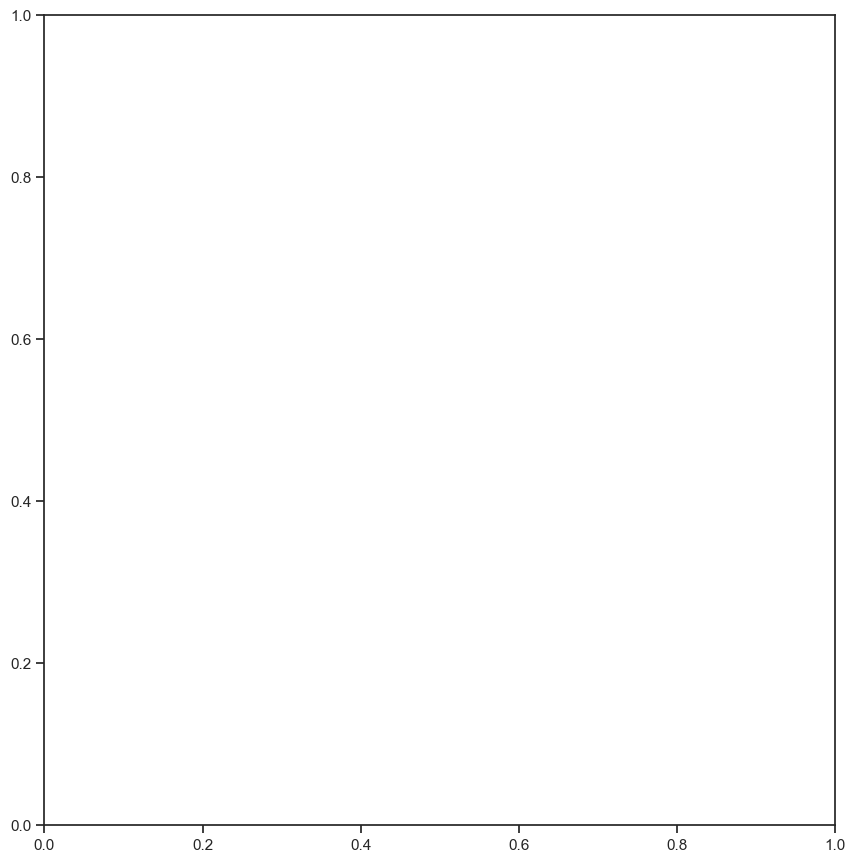

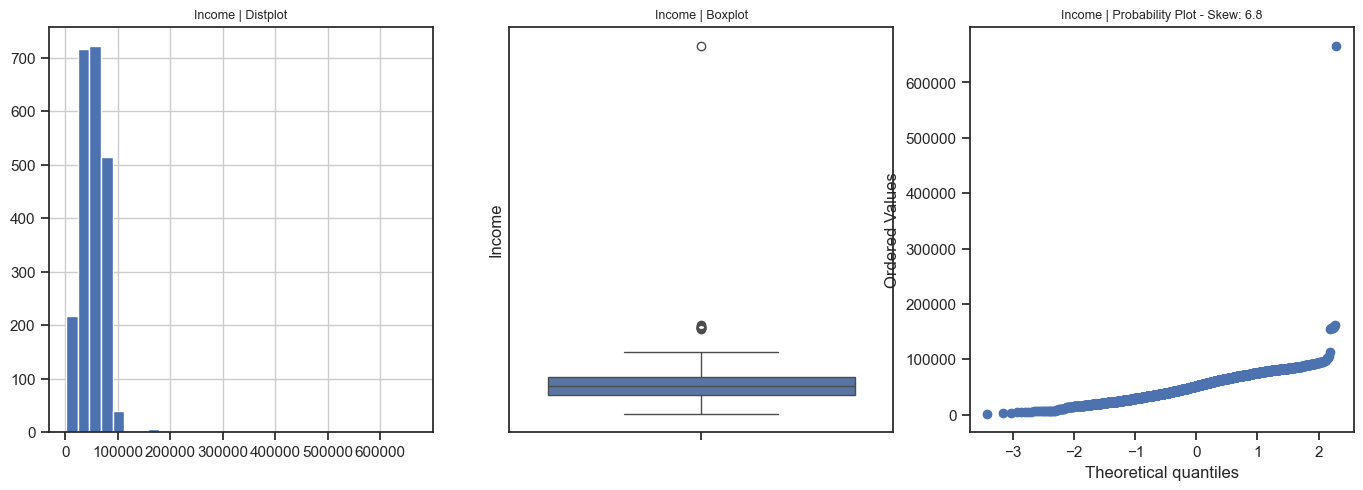

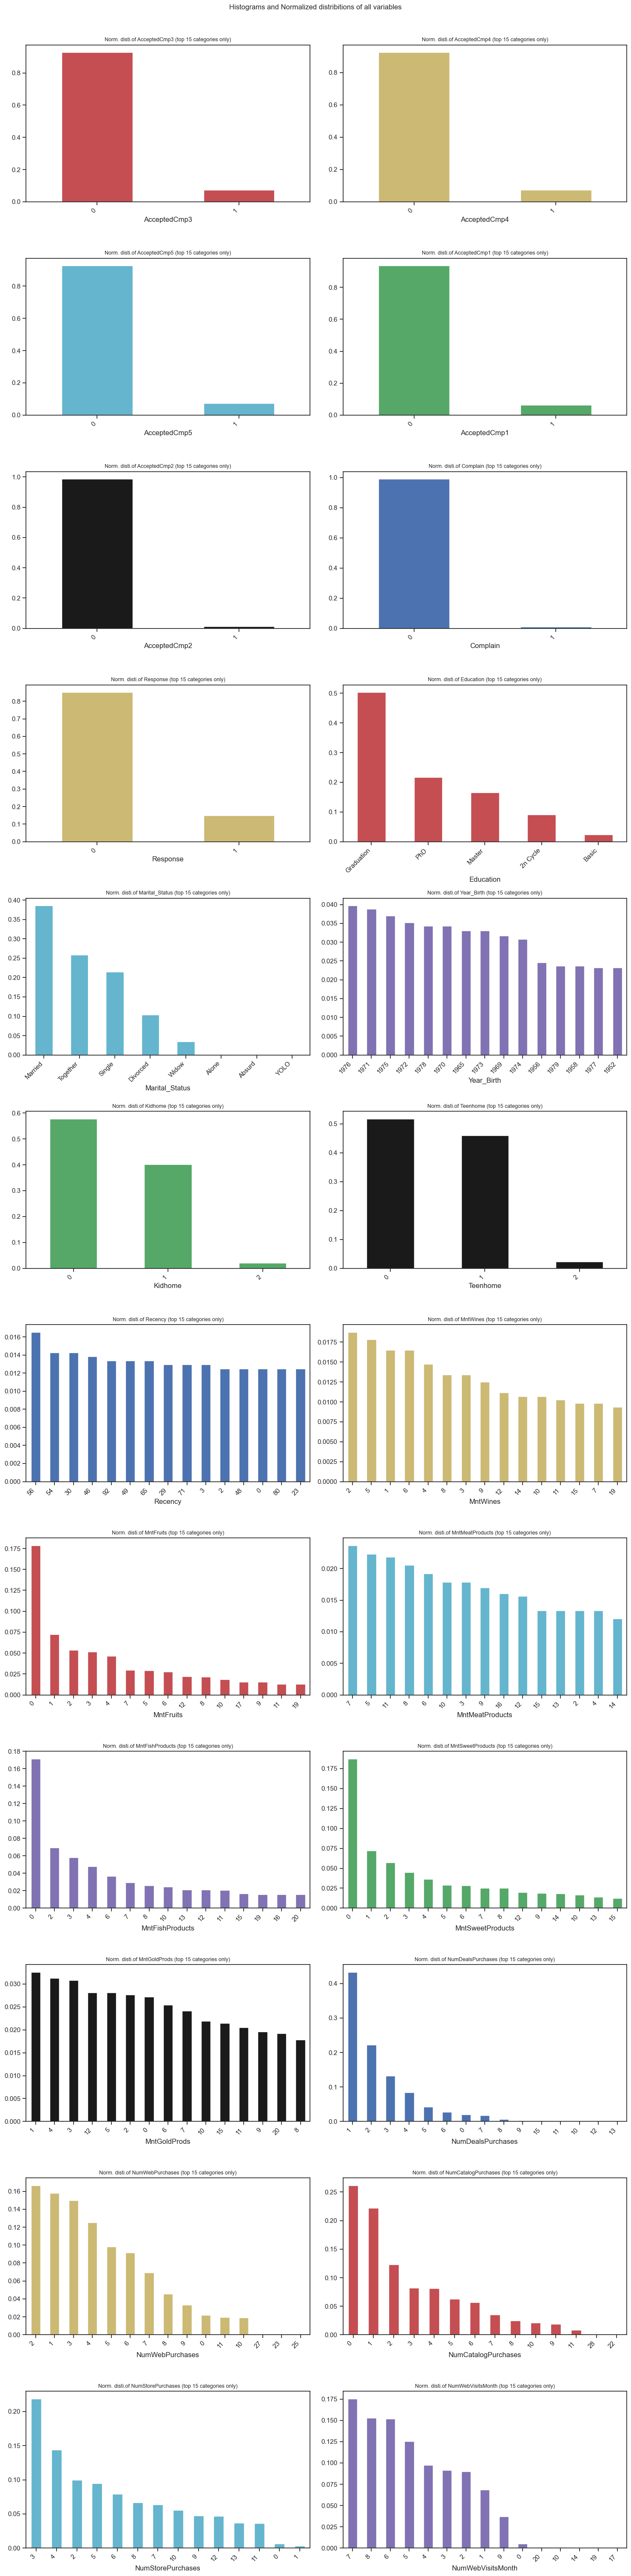

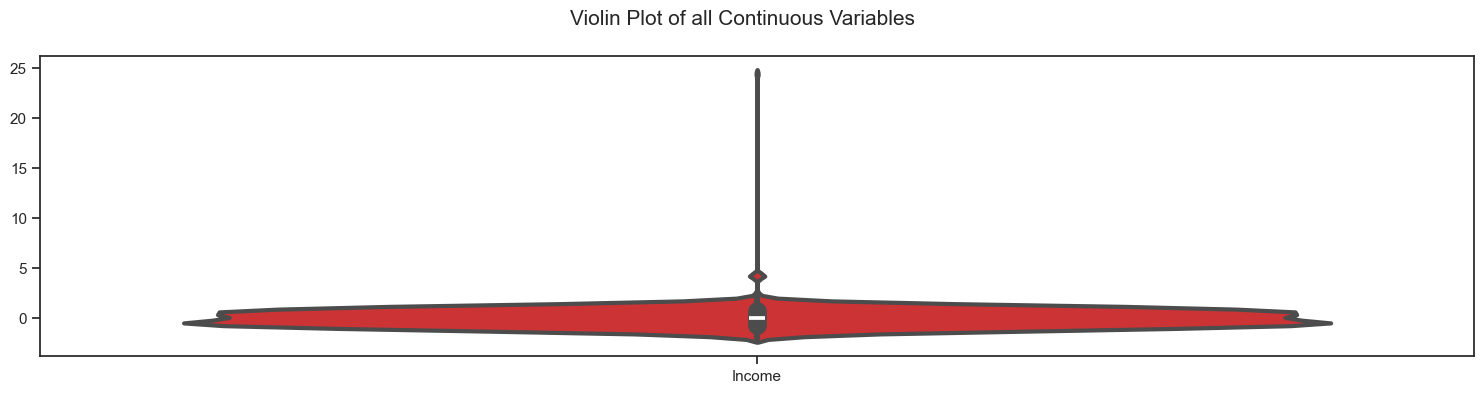

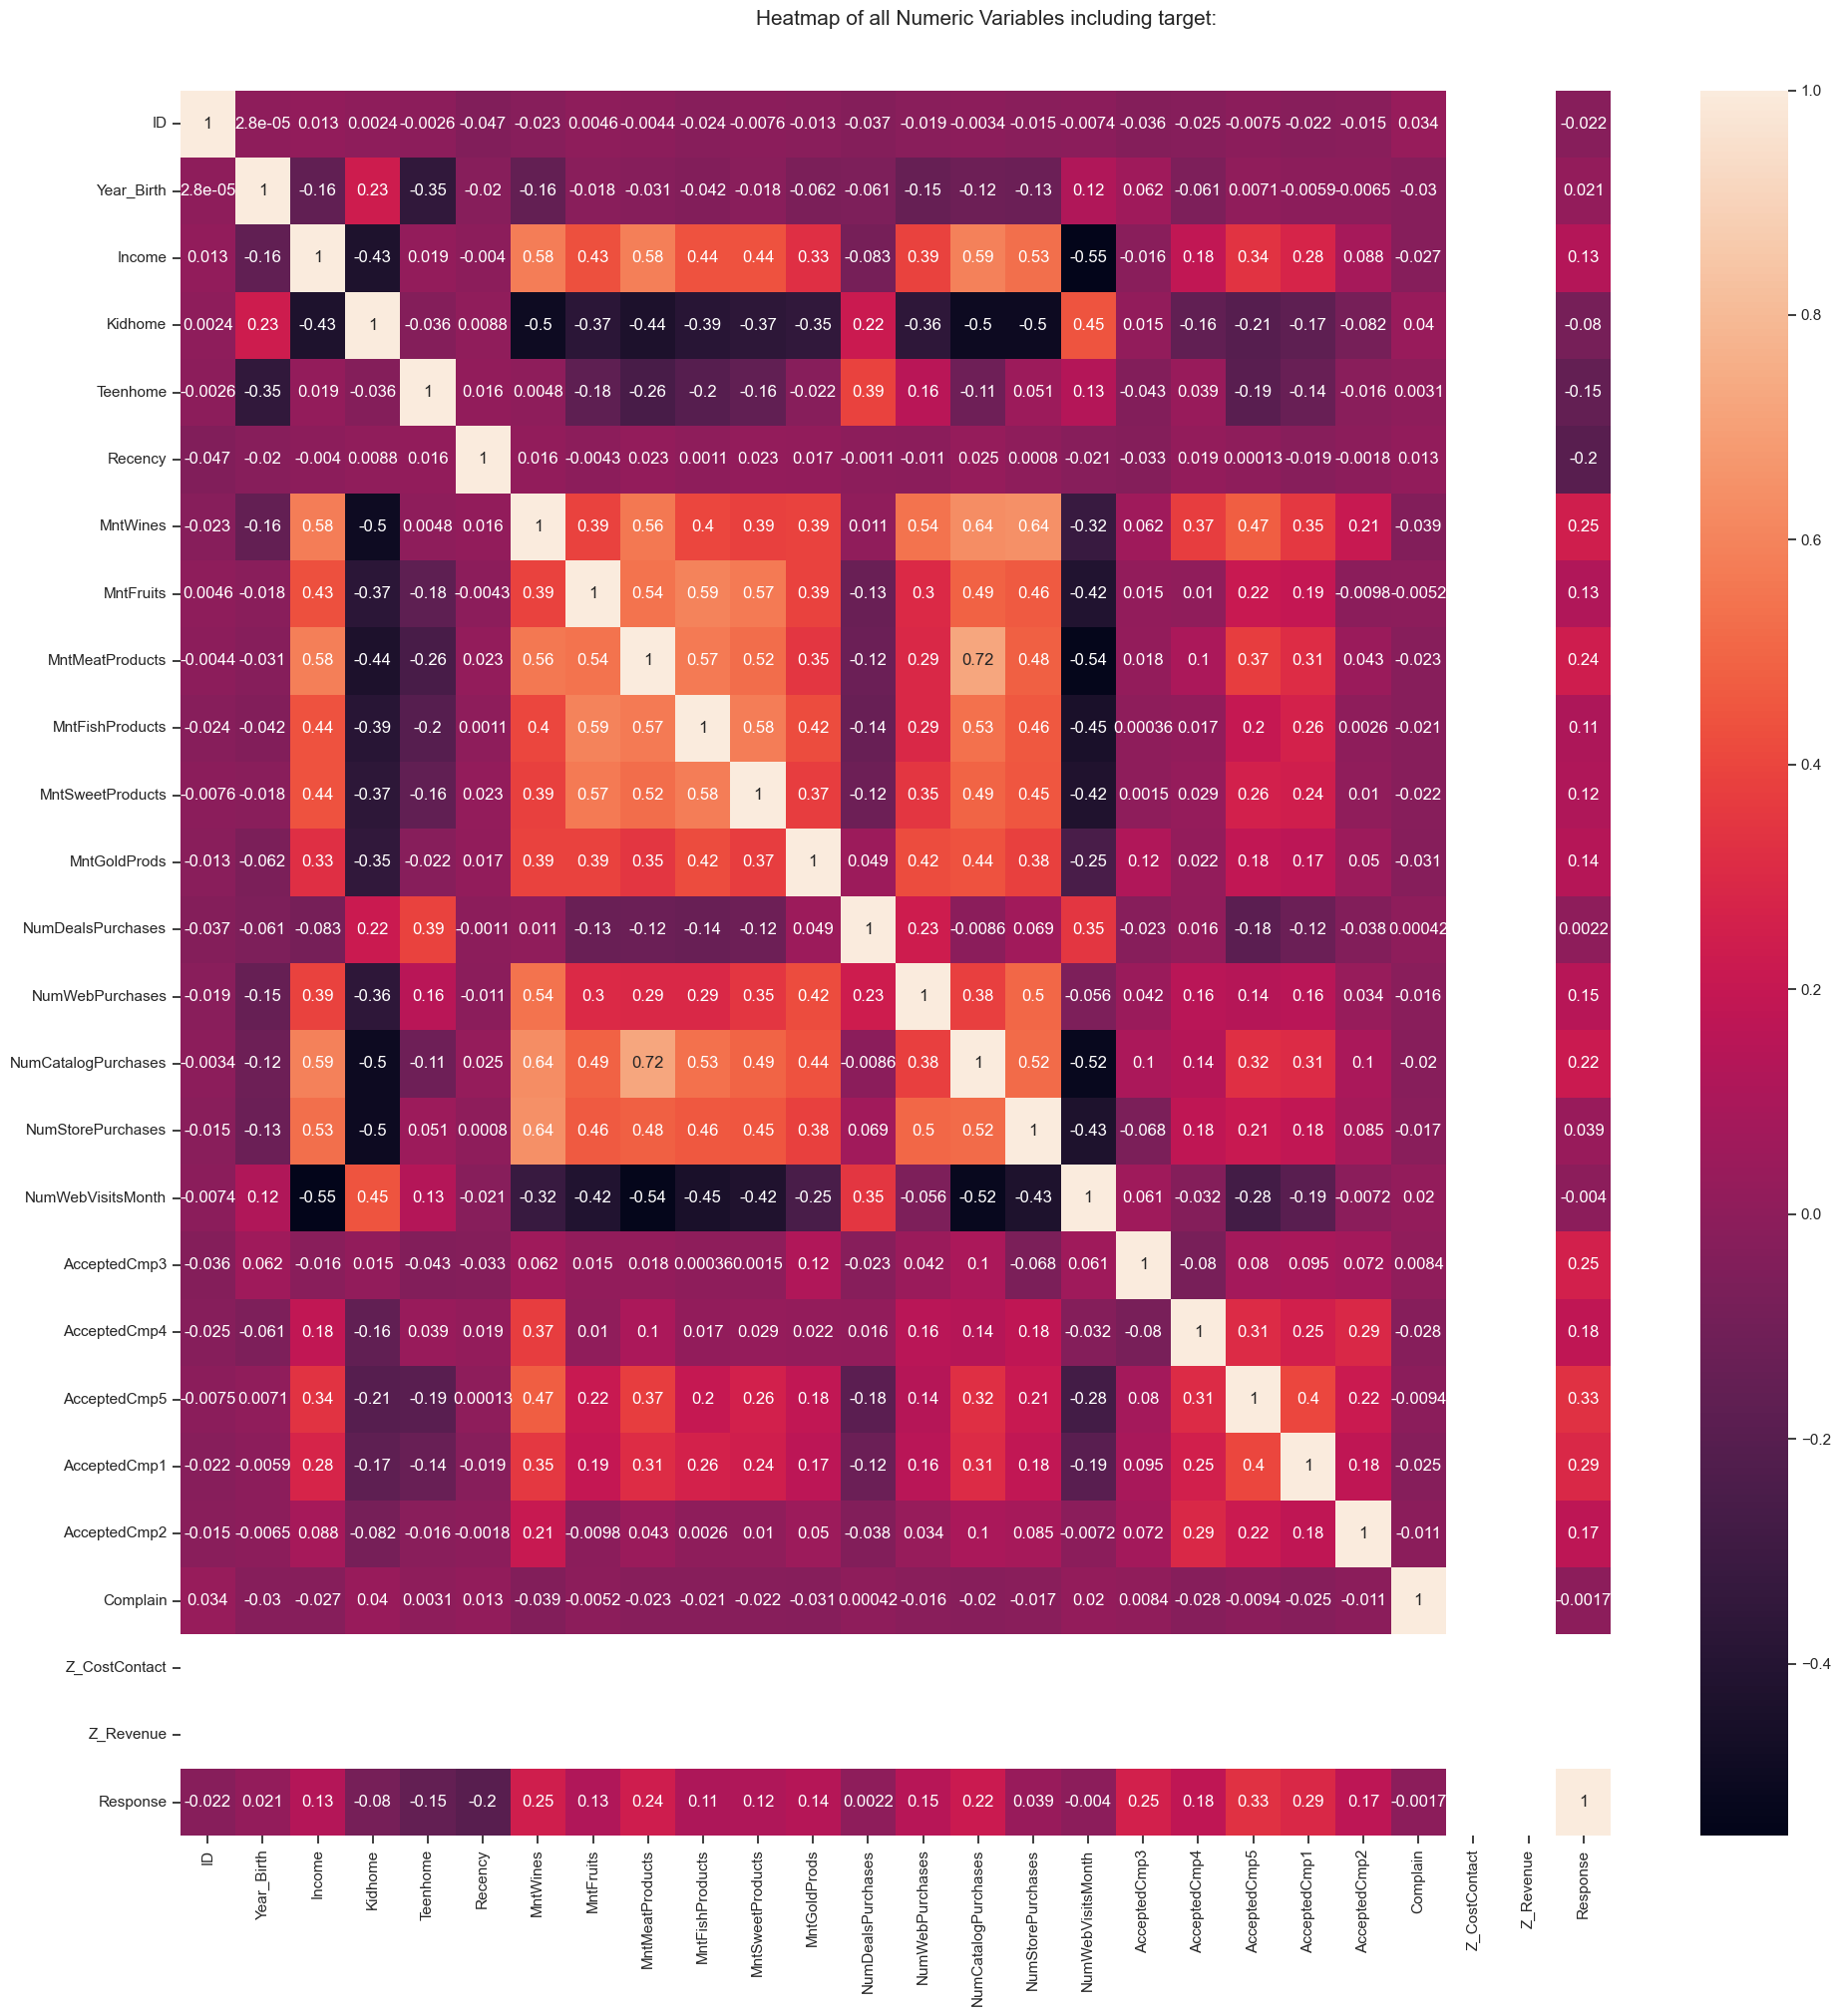

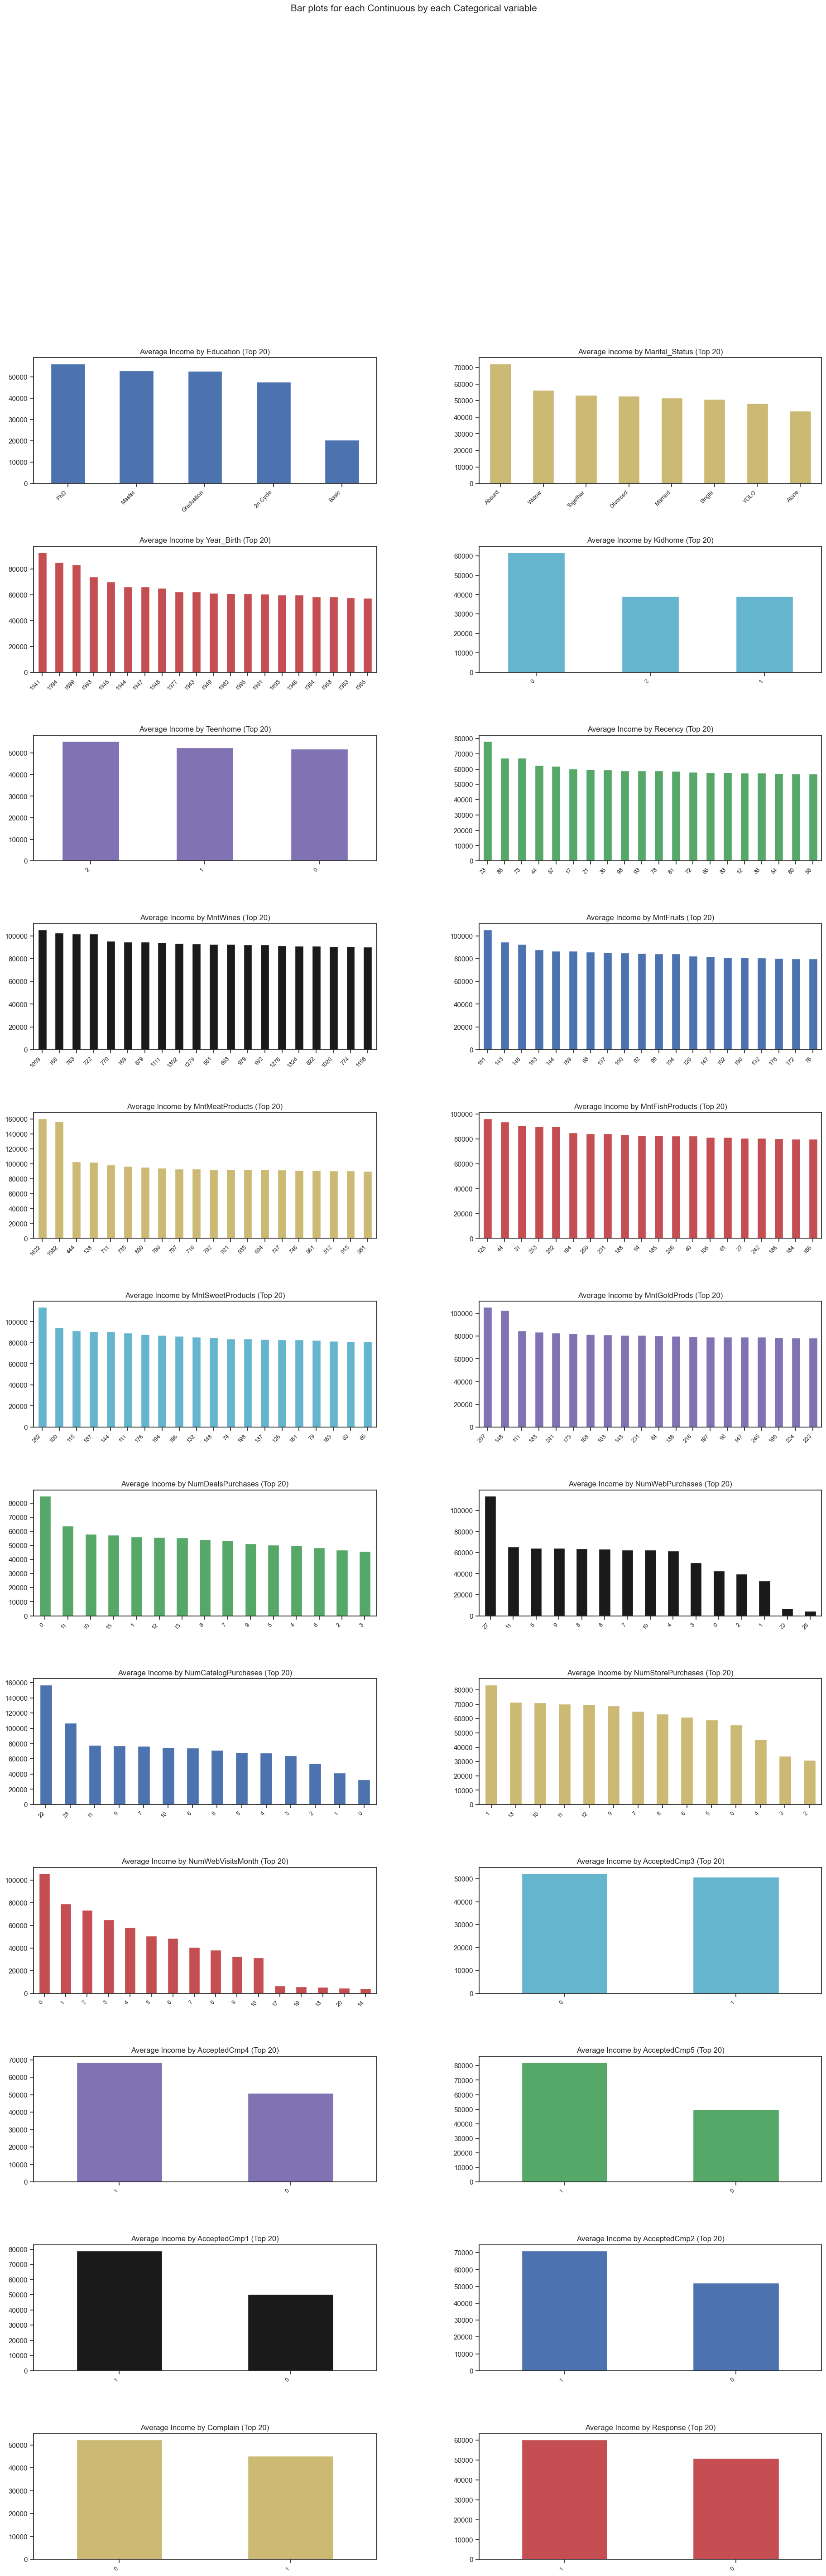

Could not draw wordcloud plot for Dt_Customer. 
Looks like you are missing some required data for this feature.

To download the necessary data, simply run

    python -m textblob.download_corpora

or use the NLTK downloader to download the missing data: http://nltk.org/data.html
If this doesn't fix the problem, file an issue at https://github.com/sloria/TextBlob/issues.

All Plots done
Time to run AutoViz = 5 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]   

In [23]:
from autoviz.AutoViz_Class import AutoViz_Class
import pandas as pd

df = pd.read_csv(r"C:\Users\Admin\OneDrive\Documents\lab01\Data_Analysis_SGU_2025\Data_analysis\practice\Lab1_Nhom\1.3.4 Bài tập thực hành 2\dataset\marketing_campaign.csv", sep = '\t', encoding='utf-8')
AV = AutoViz_Class()

%matplotlib inline
dft = AV.AutoViz(
    filename="",         # để trống nếu bạn truyền DataFrame
    dfte=df,             # DataFrame của bạn
    depVar="",      
    sep="\t", 
    header=0,
    verbose=1,
    lowess=False,
    chart_format="inline",
    max_rows_analyzed=50000,
    max_cols_analyzed=30,
)


Khi chạy, AutoViz sẽ:

- Liệt kê báo cáo chất lượng dữ liệu: số giá trị null, biến có hầu như không biến động, outliers, biến bị dư thừa.

- Cho mỗi biến số (“continuous”), vẽ histogram, box plot, scatter với biến mục tiêu nếu có.

- Cho các biến phân loại (“categorical”), vẽ biểu đồ tần suất (bar plot), so sánh nhóm theo biến mục tiêu.

- Vẽ ma trận tương quan (correlation heatmap) giữa các biến số.

- Nếu có biến ngày, có thể vẽ biểu đồ theo trend/series theo thời gian.

- Bố trí các đồ thị trong file HTML để bạn có thể xem tương tác, zoom, hover để xem chi tiết.

**Bước 3: Phân tích kết quả**

Khi xem báo cáo, bạn có thể tìm:

- Biến nào phân phối lệch, nhiều outliers

- Biến nào có tương quan mạnh với biến mục tiêu (Response)

- Nhóm khách hàng (phân loại) nào phản hồi nhiều hơn

- Liên hệ giữa biến số: ví dụ thu nhập và chi tiêu, tần suất mua hàng

- Các biến ít thông tin (“low variance”) có thể loại bỏ

Ví dụ: nếu biến income có phân phối rất lệch, bạn có thể chuyển log hoặc tạo nhóm. Nếu biến gender có ảnh hưởng đến tỉ lệ phản hồi, bạn có thể so sánh bằng bar plot. Nếu biến age là biến số, bạn có histogram + box plot + scatter (age vs spending) + tương quan với response.

**Bước 4: Quyết định xử lý dữ liệu tiếp theo**

Dựa vào kết quả AutoViz, bạn có thể:

- Loại hoặc gộp biến ít thông tin

- Xử lý giá trị thiếu, outliers

- Tạo biến mới (ví dụ phân nhóm, biến tương tác)

- Chọn biến đầu vào cho mô hình ML

- Kiểm tra giả thuyết: ví dụ “Khách hàng thu nhập cao phản hồi cao hơn?” — xem biểu đồ phân nhóm theo thu nhập

### **Hạn chế & lưu ý khi dùng AutoViz**

- Vì AutoViz cố gắng vẽ rất nhiều đồ thị, nếu dataset có rất nhiều cột hoặc rất nhiều hàng, nó có thể chậm hoặc quá tải. Bạn nên dùng giới hạn max_rows_analyzed và max_cols_analyzed. 

- AutoViz tự chọn loại đồ thị, nhưng đôi khi không phù hợp với mục đích đặc thù bạn muốn (ví dụ muốn xem phân phối log, hoặc muốn đồ thị tùy chỉnh). Trong những trường hợp đó, bạn vẫn cần viết code thủ công với seaborn / matplotlib.

- Nếu dữ liệu có biến rất nhiều giá trị (categorical với hàng trăm mục), AutoViz có thể không hiển thị hết (có thể bỏ qua hoặc phân nhóm).

- Đôi khi kết nối giữa biến mục tiêu và biến số yếu, đồ thị mặc định có thể không rõ ràng — bạn cần lọc hoặc zoom vào vùng quan tâm.

- AutoViz phụ thuộc vào các thư viện vẽ như matplotlib, hvPlot, bokeh, v.v. — nếu môi trường chưa hỗ trợ (như môi trường không có GUI), có thể gặp lỗi.